## 04_Result - 모델 평가/시각화

`03_ML_2.ipynb`에서 저장한 예측값(`predictions/`)을 불러와 성능 지표를 계산하고 시각화합니다.
- 입력: `predictions/{dataset}_{model}_{validation|test}_pred.csv` (컬럼: y_true, y_pred, score(optional))
- 출력: 요약 지표 테이블, F1/ROC-AUC 비교 바차트, 최적 모델 혼동행렬/ROC/PR 곡선
- 해석: 자동으로 간단 해석 텍스트를 생성합니다.

## 1. 환경 설정과 데이터 로드

In [2]:
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
# 예측 파일 로드
PRED_DIR = Path("predictions")
if not PRED_DIR.exists():
    raise FileNotFoundError("predictions 폴더가 없습니다. 먼저 03_ML_2.ipynb를 실행하세요.")

# (dataset, model, split) -> DataFrame 저장
pred_store = {}
records = []

for path_str in sorted(glob.glob(str(PRED_DIR / "*_pred.csv"))):
    path = Path(path_str)
    base = path.stem.replace("_pred", "")  # example: median_log_reg_validation
    parts = base.split("_")
    split = parts[-1]
    dataset = parts[0]
    model = "_".join(parts[1:-1])

    df = pd.read_csv(path)
    pred_store[(dataset, model, split)] = df

    has_score = "score" in df.columns
    y_true = df["y_true"]
    y_pred = df["y_pred"]
    score = df["score"] if has_score else None

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if has_score:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, score)
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    records.append({
        "dataset": dataset,
        "model": model,
        "split": split,
        "has_score": has_score,
        **metrics,
    })

metrics_df = pd.DataFrame(records)
metrics_df.head()


,dataset,model,split,has_score,accuracy,precision,recall,f1,roc_auc
0,iterative,gradient_boosting,test,True,0.714286,0.613636,0.500000,0.551020,0.799259
1,iterative,gradient_boosting,validation,True,0.779221,0.700000,0.648148,0.673077,0.867130
2,iterative,knn,test,True,0.746753,0.641509,0.629630,0.635514,0.777963
3,iterative,knn,validation,True,0.753247,0.673913,0.574074,0.620000,0.809630
4,iterative,log_reg,test,True,0.733766,0.606557,0.685185,0.643478,0.812407


In [4]:
# 검증/테스트 성능 테이블 정렬
val_df = metrics_df[metrics_df["split"] == "validation"].copy()
test_df = metrics_df[metrics_df["split"] == "test"].copy()

val_df = val_df.sort_values(["dataset", "f1"], ascending=[True, False])
test_df = test_df.sort_values(["dataset", "f1"], ascending=[True, False])

print("[Validation 성능 상위]")
display(val_df)
print("[Test 성능 상위]")
display(test_df)


[Validation 성능 상위]


,dataset,model,split,has_score,accuracy,precision,recall,f1,roc_auc
9,iterative,svc_rbf,validation,True,0.746753,0.611940,0.759259,0.677686,0.856481
1,iterative,gradient_boosting,validation,True,0.779221,0.700000,0.648148,0.673077,0.867130
5,iterative,log_reg,validation,True,0.759740,0.649123,0.685185,0.666667,0.850926
7,iterative,random_forest,validation,True,0.779221,0.708333,0.629630,0.666667,0.869907
11,iterative,xgboost,validation,True,0.759740,0.688889,0.574074,0.626263,0.837593
3,iterative,knn,validation,True,0.753247,0.673913,0.574074,0.620000,0.809630
21,median,svc_rbf,validation,True,0.759740,0.626866,0.777778,0.694215,0.854074
15,median,knn,validation,True,0.785714,0.714286,0.648148,0.679612,0.842222
19,median,random_forest,validation,True,0.785714,0.714286,0.648148,0.679612,0.868241
17,median,log_reg,validation,True,0.753247,0.637931,0.685185,0.660714,0.852407


[Test 성능 상위]


,dataset,model,split,has_score,accuracy,precision,recall,f1,roc_auc
4,iterative,log_reg,test,True,0.733766,0.606557,0.685185,0.643478,0.812407
2,iterative,knn,test,True,0.746753,0.641509,0.629630,0.635514,0.777963
8,iterative,svc_rbf,test,True,0.720779,0.587302,0.685185,0.632479,0.802593
10,iterative,xgboost,test,True,0.746753,0.653061,0.592593,0.621359,0.811667
6,iterative,random_forest,test,True,0.727273,0.630435,0.537037,0.580000,0.810741
0,iterative,gradient_boosting,test,True,0.714286,0.613636,0.500000,0.551020,0.799259
16,median,log_reg,test,True,0.727273,0.596774,0.685185,0.637931,0.814815
20,median,svc_rbf,test,True,0.727273,0.596774,0.685185,0.637931,0.810370
22,median,xgboost,test,True,0.753247,0.673913,0.574074,0.620000,0.819259
14,median,knn,test,True,0.740260,0.640000,0.592593,0.615385,0.769259


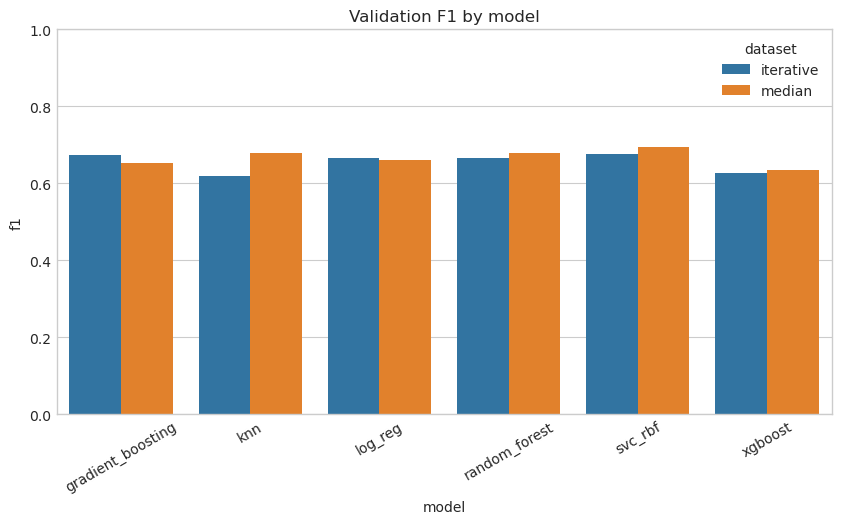

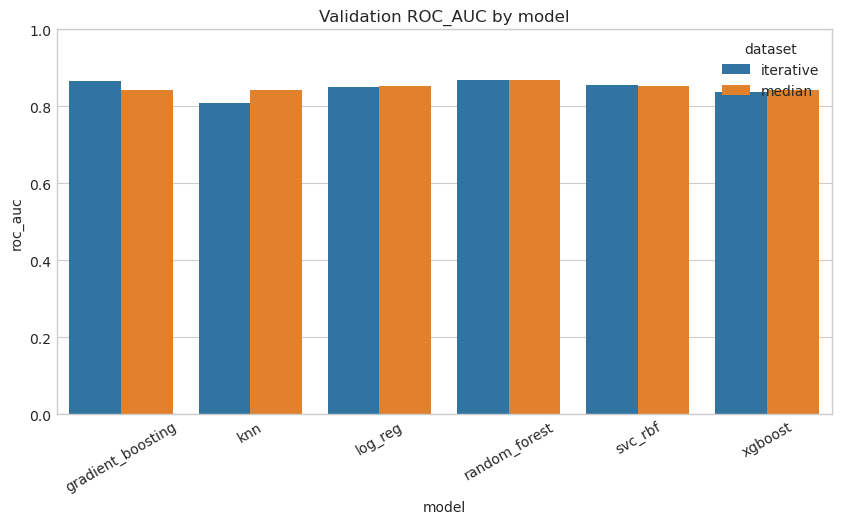

In [5]:
# F1, ROC-AUC 바차트 비교
for metric in ["f1", "roc_auc"]:
    plt.figure(figsize=(10, 5))
    plot_df = metrics_df[metrics_df["split"] == "validation"].copy()
    sns.barplot(data=plot_df, x="model", y=metric, hue="dataset")
    plt.title(f"Validation {metric.upper()} by model")
    plt.ylim(0, 1)
    plt.legend(title="dataset")
    plt.xticks(rotation=30)
    plt.show()


=== iterative | best(val F1): svc_rbf ===


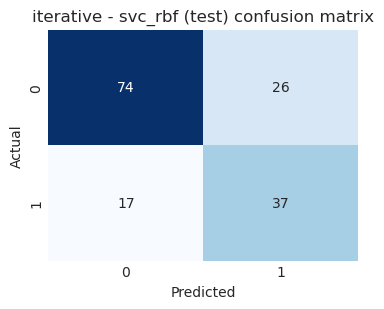

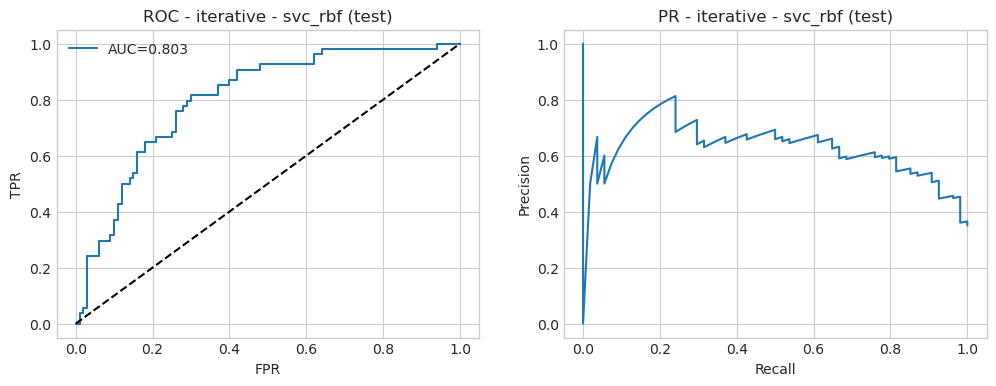

=== median | best(val F1): svc_rbf ===


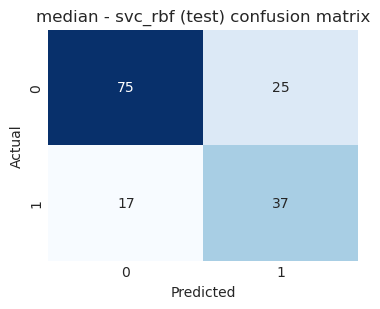

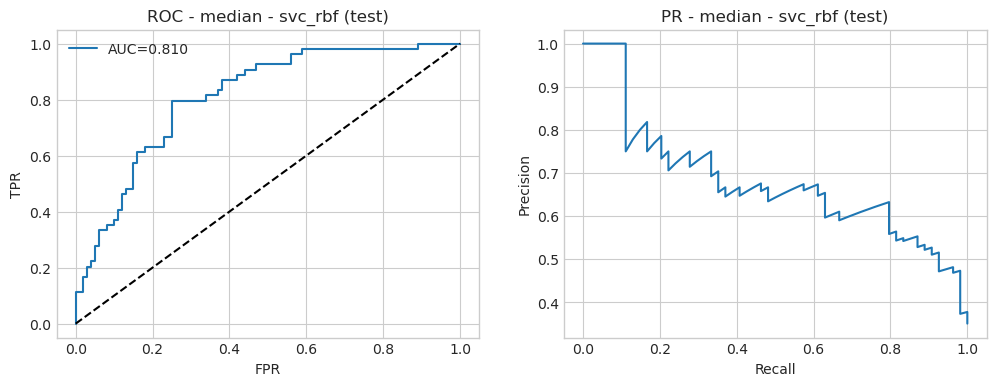

In [7]:
# 데이터셋별 최고 Validation F1 모델로 혼동행렬, ROC, PR 곡선 그리기
best_rows = (metrics_df[metrics_df["split"] == "validation"]
             .sort_values(["dataset", "f1"], ascending=[True, False])
             .groupby("dataset")
             .head(1))

for _, row in best_rows.iterrows():
    ds = row.dataset
    model = row.model
    print(f"=== {ds} | best(val F1): {model} ===")
    # 테스트셋 사용 (없으면 validation 사용)
    key = (ds, model, "test")
    split_used = "test"
    if key not in pred_store:
        key = (ds, model, "validation")
        split_used = "validation"
    pred_df = pred_store[key]

    y_true = pred_df["y_true"]
    y_pred = pred_df["y_pred"]
    y_score = pred_df["score"] if "score" in pred_df.columns else None

    # 혼동행렬
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{ds} - {model} ({split_used}) confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC/PR 곡선 (score 있을 때만)
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        prec, rec, _ = precision_recall_curve(y_true, y_score)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, y_score):.3f}")
        axes[0].plot([0, 1], [0, 1], "k--")
        axes[0].set_title(f"ROC - {ds} - {model} ({split_used})")
        axes[0].set_xlabel("FPR")
        axes[0].set_ylabel("TPR")
        axes[0].legend()

        axes[1].plot(rec, prec)
        axes[1].set_title(f"PR - {ds} - {model} ({split_used})")
        axes[1].set_xlabel("Recall")
        axes[1].set_ylabel("Precision")
        plt.show()
    else:
        print("score 컬럼이 없어 ROC/PR 곡선을 건너뜁니다.")
